# TSPLIB61：Augmented Gap 逐实例对比（4 种 init/iter 组合）

对比 4 个日志（同一批 61 个 TSPLIB 实例）：
- `lehd_lehd_30.txt`：LEHD 初始化 + LEHD 迭代
- `lehd_glop.txt`：LEHD 初始化 + GLOP 迭代
- `glop_glop.txt`：GLOP 初始化 + GLOP 迭代
- `glop_lehd_30.txt`：GLOP 初始化 + LEHD 迭代

只比较 **Augmented Gap(%)**（越小越好），并做：
1. 逐实例 winner（min gap）
2. Win 次数（strict / tie）
3. 两两对比矩阵（A 更好 / 持平 / 更差）
4. 分桶分析（按规模 n）
5. 组件贡献分析（固定 init 看 iter；固定 iter 看 init；组合 vs 纯）


In [ ]:
from __future__ import annotations

from pathlib import Path
import re
from collections import defaultdict
from html import escape
import statistics as stats

try:
    import numpy as np
except Exception:
    np = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

try:
    from IPython.display import display, HTML
except Exception:
    display = None
    HTML = None


def find_repo_root(start: Path, max_up: int = 8) -> Path:
    p = start.resolve()
    for _ in range(max_up + 1):
        if (p / "benchmarks").exists() and (p / "EasyNCO").exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError("Cannot find repo root (expected both benchmarks/ and EasyNCO/)")


NUM = r"[+-]?(?:\d+\.\d+|\d+)(?:[eE][+-]?\d+)?"
EVAL_LINE_RE = re.compile(
    rf"\[(?P<date>\d{{4}}-\d{{2}}-\d{{2}} \d{{2}}:\d{{2}}:\d{{2}}),(?P<ms>\d{{3}})\].*?"
    rf"Eval ==> Problem\[(?P<problem>[^\]]+)\], Size\[(?P<size>\d+)\], Name\[(?P<name>[^\]]+)\].*?"
    rf"Score: (?P<score>{NUM}), Augmented Score: (?P<aug_score>{NUM}), "
    rf"Gap: (?P<gap>{NUM})%, Augmented Gap: (?P<aug_gap>{NUM})%"
)


def parse_eval_log_to_map(path: Path) -> tuple[dict[str, dict], list[str]]:
    """Return (inst->record, duplicates). Keep the last occurrence if duplicated."""
    text = path.read_text(encoding="utf-8", errors="ignore")
    out: dict[str, dict] = {}
    dup: list[str] = []
    for m in EVAL_LINE_RE.finditer(text):
        inst = m.group("name").strip()
        rec = {
            "instance": inst,
            "problem": m.group("problem").strip(),
            "n": int(m.group("size")),
            "aug_gap": float(m.group("aug_gap")),
        }
        if inst in out:
            dup.append(inst)
        out[inst] = rec
    return out, dup


def display_table(rows, headers, title: str | None = None, max_rows: int = 50):
    if title:
        print("\n" + title)
    rows = list(rows)
    show = rows[:max_rows]
    truncated = len(rows) > max_rows
    if display is None or HTML is None:
        print("\t".join(headers))
        for r in show:
            print("\t".join(str(r.get(h, "")) for h in headers))
        if truncated:
            print(f"... (仅展示前 {max_rows} 行，共 {len(rows)} 行)")
        return
    html = ["<table style='border-collapse:collapse; font-family:monospace; font-size:12px'>"]
    html.append("<thead><tr>")
    for h in headers:
        html.append(
            "<th style='border:1px solid #ccc; padding:4px; text-align:left'>"
            + escape(str(h))
            + "</th>"
        )
    html.append("</tr></thead><tbody>")
    for r in show:
        html.append("<tr>")
        for h in headers:
            html.append(
                "<td style='border:1px solid #ccc; padding:4px'>"
                + escape(str(r.get(h, "")))
                + "</td>"
            )
        html.append("</tr>")
    html.append("</tbody></table>")
    if truncated:
        html.append(
            f"<div style='color:#666; font-size:12px'>(仅展示前 {max_rows} 行，共 {len(rows)} 行)</div>"
        )
    display(HTML("".join(html)))


def bucket_n(n: int) -> str:
    if n <= 100:
        return "<=100"
    if n <= 300:
        return "101-300"
    if n <= 1000:
        return "301-1000"
    return ">1000"


def pairwise_counts(a_map: dict[str, float], b_map: dict[str, float], instances: list[str], eps: float = 1e-9):
    lt = eq = gt = 0
    deltas = []
    for inst in instances:
        da = a_map[inst]
        db = b_map[inst]
        d = da - db
        deltas.append(d)
        if d < -eps:
            lt += 1
        elif d > eps:
            gt += 1
        else:
            eq += 1
    return {
        "A_better": lt,
        "tie": eq,
        "A_worse": gt,
        "mean(A-B)": stats.mean(deltas) if deltas else None,
        "median(A-B)": stats.median(deltas) if deltas else None,
        "min(A-B)": min(deltas) if deltas else None,
        "max(A-B)": max(deltas) if deltas else None,
    }


In [ ]:
# 1) 定位并读取 4 个日志
repo_root = find_repo_root(Path.cwd())
log_dir = repo_root / "benchmarks" / "results" / "tsplib61"
runs = {
    "lehd→lehd": log_dir / "lehd_lehd_30.txt",
    "lehd→glop": log_dir / "lehd_glop.txt",
    "glop→glop": log_dir / "glop_glop.txt",
    "glop→lehd": log_dir / "glop_lehd_30.txt",
}

run_rec = {}
run_gap = {}
run_dup = {}

for name, path in runs.items():
    rec_map, dup = parse_eval_log_to_map(path)
    run_rec[name] = rec_map
    run_dup[name] = dup
    run_gap[name] = {k: v["aug_gap"] for k, v in rec_map.items()}
    print(f"{name:9s}: {len(rec_map)} instances (dups={len(dup)})  file={path.name}")

inst_sets = {k: set(v.keys()) for k, v in run_rec.items()}
common = set.intersection(*inst_sets.values())
print("\ncommon instances:", len(common))


lehd→lehd: 61 instances (dups=0)  file=lehd_lehd_30.txt
lehd→glop: 61 instances (dups=0)  file=lehd_glop.txt
glop→glop: 61 instances (dups=0)  file=glop_glop.txt
glop→lehd: 61 instances (dups=0)  file=glop_lehd_30.txt

common instances: 61


In [ ]:
# 2) 一致性检查：实例集合、重复、规模 n 是否一致
methods = list(runs.keys())
common_sorted = sorted(common)

# 检查：每个方法是否缺失/多余
for m in methods:
    missing = sorted(common - set(run_rec[m].keys()))
    extra = sorted(set(run_rec[m].keys()) - common)
    if missing or extra:
        print(m, "missing", len(missing), "extra", len(extra))

# 检查：n 是否一致（以 lehd→lehd 为参考）
ref = methods[0]
inst_n = {inst: run_rec[ref][inst]["n"] for inst in common_sorted}
n_mismatch = []
for m in methods[1:]:
    for inst in common_sorted:
        if run_rec[m][inst]["n"] != inst_n[inst]:
            n_mismatch.append((inst, ref, inst_n[inst], m, run_rec[m][inst]["n"]))
print("n mismatch:", len(n_mismatch))
if n_mismatch:
    print(n_mismatch[:10])

ns = sorted(set(inst_n.values()))
print("n unique:", len(ns), "min", min(ns), "max", max(ns))


n mismatch: 0
n unique: 51 min 51 max 1889


In [ ]:
# 3) 逐实例对比表：Augmented Gap(%) + winner（min 为胜）
EPS = 1e-9
rows = []
for inst in common_sorted:
    vals = {m: run_gap[m][inst] for m in methods}
    best = min(vals.values())
    winners = [m for m, v in vals.items() if abs(v - best) <= EPS]
    row = {"instance": inst, "n": inst_n[inst]}
    row.update({m: vals[m] for m in methods})
    row["winner"] = ",".join(winners)
    rows.append(row)

# 默认按 n / instance 排序，方便读
rows_sorted = sorted(rows, key=lambda r: (r["n"], r["instance"]))
display_table(
    rows_sorted,
    ["instance", "n"] + methods + ["winner"],
    title="逐实例 Augmented Gap(%)（越小越好）",
    max_rows=30,
)



逐实例 Augmented Gap(%)（越小越好）


instance,n,lehd→lehd,lehd→glop,glop→glop,glop→lehd,winner
eil51,51,0.6999,1.5218,2.2059,0.6741,glop→lehd
berlin52,52,0.0314,0.0314,0.0314,0.0314,"lehd→lehd,lehd→glop,glop→glop,glop→lehd"
st70,70,0.3125,0.3125,1.1222,0.3125,"lehd→lehd,lehd→glop,glop→lehd"
eil76,76,1.1838,2.1771,2.3696,1.1838,"lehd→lehd,glop→lehd"
pr76,76,0.2192,0.2192,0.8183,0.1073,glop→lehd
rat99,99,0.6807,1.0988,0.6807,0.6807,"lehd→lehd,glop→glop,glop→lehd"
kroA100,100,0.0162,0.0162,0.4055,0.0162,"lehd→lehd,lehd→glop,glop→lehd"
kroB100,100,0.014,0.2544,1.0677,0.2273,lehd→lehd
kroC100,100,0.0235,0.0085,0.4978,0.0085,"lehd→glop,glop→lehd"
kroD100,100,0.0014,0.0014,0.425,0.0014,"lehd→lehd,lehd→glop,glop→lehd"


In [ ]:
# 4) 方法级描述统计（只基于 Augmented Gap）
def describe(vals: list[float]) -> dict:
    qs = [0.05, 0.25, 0.5, 0.75, 0.95]
    out = {
        "mean": stats.mean(vals),
        "median": stats.median(vals),
        "stdev": stats.pstdev(vals),
        "min": min(vals),
        "max": max(vals),
    }
    if np is not None:
        arr = np.array(vals, dtype=float)
        for q in qs:
            out[f"q{int(q*100):02d}"] = float(np.quantile(arr, q))
    return out

desc_rows = []
for m in methods:
    vals = [run_gap[m][inst] for inst in common_sorted]
    d = describe(vals)
    desc_rows.append({"method": m, **{k: round(v, 6) for k, v in d.items()}})
display_table(
    desc_rows,
    ["method", "mean", "median", "stdev", "min", "q05", "q25", "q50", "q75", "q95", "max"],
    title="方法级 gap 分布摘要",
)



方法级 gap 分布摘要


method,mean,median,stdev,min,q05,q25,q50,q75,q95,max
lehd→lehd,1.733848,0.9106,2.03432,-0.5745,0.0014,0.0857,0.9106,2.6449,5.5034,7.4343
lehd→glop,2.344292,1.325,2.854782,-0.0988,0.0014,0.2462,1.325,3.4646,8.4323,11.3339
glop→glop,3.358367,2.457,2.84851,0.0012,0.3139,0.8183,2.457,5.0738,8.2679,12.9036
glop→lehd,1.877259,0.9168,2.196121,0.0014,0.0034,0.1339,0.9168,2.9889,6.0621,9.3328


In [ ]:
# 5) Win 统计（strict / tie）+ 并列情况
win_strict = defaultdict(int)
win_tie = defaultdict(int)
tie_size_hist = defaultdict(int)
strict_wins = defaultdict(list)
tie_wins = defaultdict(list)

for r in rows:
    inst = r["instance"]
    vals = [(m, r[m]) for m in methods]
    best = min(v for _, v in vals)
    winners = [m for m, v in vals if abs(v - best) <= EPS]
    if len(winners) == 1:
        win_strict[winners[0]] += 1
        strict_wins[winners[0]].append(inst)
    else:
        tie_size_hist[len(winners)] += 1
        for w in winners:
            win_tie[w] += 1
            tie_wins[w].append(inst)

summary = []
for m in methods:
    summary.append(
        {
            "method": m,
            "strict_win": win_strict[m],
            "tie_win": win_tie[m],
            "win_including_ties": win_strict[m] + win_tie[m],
        }
    )
summary = sorted(summary, key=lambda x: (-x["win_including_ties"], -x["strict_win"]))
display_table(summary, ["method", "strict_win", "tie_win", "win_including_ties"], title="Win 次数统计")

print("\nTie-size histogram (how many methods tied for best):")
print(dict(sorted(tie_size_hist.items())))

# 每个方法列出 strict win 的前若干实例（便于写论证）
for m in methods:
    print(f"\n{m} strict wins ({len(strict_wins[m])}):", ", ".join(sorted(strict_wins[m])[:20]), "..." if len(strict_wins[m]) > 20 else "")



Win 次数统计


method,strict_win,tie_win,win_including_ties
lehd→lehd,22,14,36
glop→lehd,9,14,23
lehd→glop,9,8,17
glop→glop,6,2,8



Tie-size histogram (how many methods tied for best):
{2: 8, 3: 6, 4: 1}

lehd→lehd strict wins (22): d198, d493, d657, fl1577, gil262, kroA200, kroB100, lin318, pcb442, pr136, pr144, pr226, pr299, rat195, rat575, rd400, rl1304, rl1323, rl1889, tsp225 ...

lehd→glop strict wins (9): fl417, pr1002, pr107, pr264, pr439, rat783, u1060, u1432, u724 

glop→glop strict wins (6): fl1400, nrw1379, p654, pr124, pr152, vm1748 

glop→lehd strict wins (9): bier127, ch150, d1291, eil51, kroB200, kroE100, pcb1173, pr76, vm1084 


In [ ]:
# 6) 两两对比矩阵（A vs B）
pair_rows = []
for a in methods:
    for b in methods:
        if a == b:
            continue
        res = pairwise_counts(run_gap[a], run_gap[b], common_sorted, eps=EPS)
        dominates = (res["A_worse"] == 0) and (res["A_better"] > 0)
        pair_rows.append(
            {
                "A": a,
                "B": b,
                "A_better": res["A_better"],
                "tie": res["tie"],
                "A_worse": res["A_worse"],
                "mean(A-B)": round(res["mean(A-B)"], 6),
                "median(A-B)": round(res["median(A-B)"], 6),
                "A_dominates_B": dominates,
            }
        )
pair_rows = sorted(pair_rows, key=lambda r: (r["A"], r["B"]))
display_table(
    pair_rows,
    ["A", "B", "A_better", "tie", "A_worse", "mean(A-B)", "median(A-B)", "A_dominates_B"],
    title="两两对比：A 的 Augmented Gap 更小算赢",
    max_rows=100,
)

dominance_pairs = [r for r in pair_rows if r["A_dominates_B"]]
print("\nDominance pairs:", dominance_pairs if dominance_pairs else "<none>")



两两对比：A 的 Augmented Gap 更小算赢


A,B,A_better,tie,A_worse,mean(A-B),median(A-B),A_dominates_B
glop→glop,glop→lehd,9,2,50,1.481108,1.1835,False
glop→glop,lehd→glop,14,1,46,1.014075,0.6841,False
glop→glop,lehd→lehd,9,2,50,1.62452,1.1858,False
glop→lehd,glop→glop,50,2,9,-1.481108,-1.1835,False
glop→lehd,lehd→glop,34,8,19,-0.467033,-0.1119,False
glop→lehd,lehd→lehd,16,13,32,0.143411,0.0072,False
lehd→glop,glop→glop,46,1,14,-1.014075,-0.6841,False
lehd→glop,glop→lehd,19,8,34,0.467033,0.1119,False
lehd→glop,lehd→lehd,14,10,37,0.610444,0.2227,False
lehd→lehd,glop→glop,50,2,9,-1.62452,-1.1858,False



Dominance pairs: <none>


In [ ]:
# 7) 按规模 n 分桶：每桶 win 次数 + gap 均值
bucketed = defaultdict(list)
for inst in common_sorted:
    bucketed[bucket_n(inst_n[inst])].append(inst)

bucket_rows = []
for b, insts in sorted(bucketed.items(), key=lambda kv: kv[0]):
    row = {"bucket": b, "num_instances": len(insts)}
    # 每个方法在该 bucket 的 strict win 次数（只统计 strict，避免 tie 让数字膨胀）
    for m in methods:
        row[f"{m}_strict_win"] = sum(1 for inst in insts if (len([x for x in methods if abs(run_gap[x][inst] - min(run_gap[y][inst] for y in methods)) <= EPS]) == 1 and abs(run_gap[m][inst] - min(run_gap[y][inst] for y in methods)) <= EPS))
        row[f"{m}_mean"] = round(stats.mean(run_gap[m][inst] for inst in insts), 6)
    bucket_rows.append(row)

display_table(
    bucket_rows,
    [
        "bucket",
        "num_instances",
        "lehd→lehd_strict_win",
        "lehd→glop_strict_win",
        "glop→glop_strict_win",
        "glop→lehd_strict_win",
        "lehd→lehd_mean",
        "lehd→glop_mean",
        "glop→glop_mean",
        "glop→lehd_mean",
    ],
    title="按规模分桶统计（strict win + mean gap）",
    max_rows=20,
)



按规模分桶统计（strict win + mean gap）


bucket,num_instances,lehd→lehd_strict_win,lehd→glop_strict_win,glop→glop_strict_win,glop→lehd_strict_win,lehd→lehd_mean,lehd→glop_mean,glop→glop_mean,glop→lehd_mean
101-300,24,10,2,2,3,0.599392,1.02695,1.849996,0.688779
301-1000,12,7,4,1,0,2.005075,2.779975,4.888358,2.263208
<=100,12,1,0,0,3,0.285233,0.490125,0.987267,0.270967
>1000,13,4,3,3,3,4.915046,6.085677,6.919462,5.197846


In [ ]:
# 8) 组件贡献：固定 init 看 iter；固定 iter 看 init
comparisons = [
    ("固定 init=LEHD：iter(lehd) vs iter(glop)", "lehd→lehd", "lehd→glop"),
    ("固定 init=GLOP：iter(glop) vs iter(lehd)", "glop→glop", "glop→lehd"),
    ("固定 iter=LEHD：init(lehd) vs init(glop)", "lehd→lehd", "glop→lehd"),
    ("固定 iter=GLOP：init(lehd) vs init(glop)", "lehd→glop", "glop→glop"),
]

for title, a, b in comparisons:
    res = pairwise_counts(run_gap[a], run_gap[b], common_sorted, eps=EPS)
    print("\n" + title)
    print(f"A={a}  B={b}")
    print(
        "A better / tie / A worse =",
        res["A_better"],
        res["tie"],
        res["A_worse"],
        " | mean(A-B)=",
        round(res["mean(A-B)"], 6),
        "median(A-B)=",
        round(res["median(A-B)"], 6),
    )
    # 给出提升最大的若干实例（A-B 最负表示 A 更好）
    deltas = []
    for inst in common_sorted:
        deltas.append((run_gap[a][inst] - run_gap[b][inst], inst, inst_n[inst]))
    deltas.sort()
    print("  top-5 A much better:", deltas[:5])
    print("  top-5 A much worse :", deltas[-5:])



固定 init=LEHD：iter(lehd) vs iter(glop)
A=lehd→lehd  B=lehd→glop
A better / tie / A worse = 37 10 14  | mean(A-B)= -0.610444 median(A-B)= -0.2227
  top-5 A much better: [(-4.5291, 'd493', 493), (-4.4925999999999995, 'd198', 198), (-4.215300000000001, 'fl1400', 1400), (-3.8995999999999995, 'fl1577', 1577), (-3.7611, 'p654', 654)]
  top-5 A much worse : [(0.7048, 'pr439', 439), (1.6412, 'pr107', 107), (1.9006000000000003, 'fl417', 417), (2.3539, 'u1060', 1060), (3.5655, 'pr264', 264)]

固定 init=GLOP：iter(glop) vs iter(lehd)
A=glop→glop  B=glop→lehd
A better / tie / A worse = 9 2 50  | mean(A-B)= 1.481108 median(A-B)= 1.1835
  top-5 A much better: [(-4.2309, 'pr264', 264), (-3.2903000000000002, 'fl1400', 1400), (-1.5889999999999995, 'u1060', 1060), (-1.2635000000000005, 'fl1577', 1577), (-1.2581999999999995, 'p654', 654)]
  top-5 A much worse : [(4.4395, 'd1291', 1291), (4.8274, 'rl1323', 1323), (6.2753, 'pcb442', 442), (6.841500000000001, 'rl1889', 1889), (7.5487, 'ts225', 225)]

固定 iter=L

In [ ]:
# 9) 证明“组合有效”：best(composed) vs best(pure)
pure = ["lehd→lehd", "glop→glop"]
composed = ["lehd→glop", "glop→lehd"]

delta_rows = []
better = equal = worse = 0
for inst in common_sorted:
    best_pure = min(run_gap[m][inst] for m in pure)
    best_comp = min(run_gap[m][inst] for m in composed)
    d = best_comp - best_pure
    if d < -EPS:
        better += 1
    elif d > EPS:
        worse += 1
    else:
        equal += 1
    delta_rows.append(
        {
            "instance": inst,
            "n": inst_n[inst],
            "best_pure": best_pure,
            "best_composed": best_comp,
            "delta(composed-pure)": d,
        }
    )

print("better / equal / worse:", better, equal, worse)
deltas = [r["delta(composed-pure)"] for r in delta_rows]
print(
    "delta stats: mean=", round(stats.mean(deltas), 6),
    "median=", round(stats.median(deltas), 6),
    "min=", round(min(deltas), 6),
    "max=", round(max(deltas), 6),
)

best_improve = sorted(delta_rows, key=lambda r: r["delta(composed-pure)"])
display_table(
    best_improve,
    ["instance", "n", "best_pure", "best_composed", "delta(composed-pure)"],
    title="组合显著提升的实例（delta<0 越小越好）",
    max_rows=25,
)

worst_regress = sorted(delta_rows, key=lambda r: r["delta(composed-pure)"], reverse=True)
display_table(
    worst_regress,
    ["instance", "n", "best_pure", "best_composed", "delta(composed-pure)"],
    title="组合变差的实例（delta>0 越大越差）",
    max_rows=15,
)


better / equal / worse: 19 14 28
delta stats: mean= 0.096518 median= 0.0 min= -1.9006 max= 3.2903

组合显著提升的实例（delta<0 越小越好）


instance,n,best_pure,best_composed,delta(composed-pure)
fl417,417,3.9142,2.0136,-1.9006000000000003
u1060,1060,5.0738,3.7022,-1.3716000000000004
pr439,439,1.4946,0.7898,-0.7048
vm1084,1084,4.0598,3.3856,-0.6741999999999999
pr107,107,0.5254,-0.003,-0.5284
ch150,150,0.5196,0.0445,-0.47509999999999997
rat783,783,2.6449,2.2417,-0.4032
pr1002,1002,2.4279,2.0629,-0.3650000000000002
u1432,1432,2.5219,2.284,-0.23790000000000022
kroE100,100,0.2352,0.0034,-0.2318



组合变差的实例（delta>0 越大越差）


instance,n,best_pure,best_composed,delta(composed-pure)
fl1400,1400,3.1296,6.4199,3.2903000000000002
fl1577,1577,7.4343,9.3328,1.8985000000000003
p654,654,3.5278,4.786,1.2581999999999995
vm1748,1748,4.6958,5.9299,1.2340999999999998
d493,493,2.6472,3.7186,1.0713999999999997
u159,159,-0.0103,0.7794,0.7897
rat575,575,1.4929,2.1414,0.6485000000000001
rl1889,1889,5.5034,6.0621,0.5587
tsp225,225,-0.5745,-0.0988,0.4757
rl1323,1323,4.3153,4.6163,0.30100000000000016


/tmp/ipykernel_1150335/471397902.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([data[m] for m in methods], labels=methods, showfliers=True)


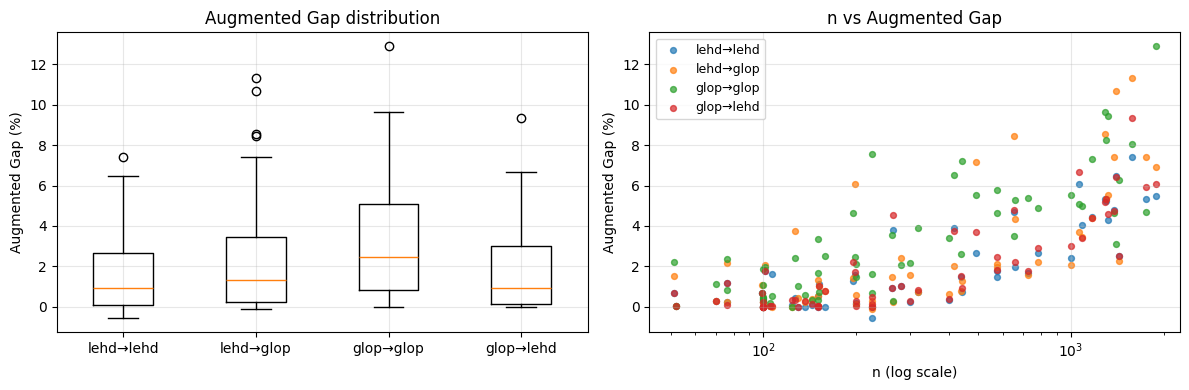

In [ ]:
# 10) 可视化（可选）：gap 分布 & n-趋势
if plt is None or np is None:
    print("matplotlib/numpy 不可用，跳过绘图")
else:
    data = {m: np.array([run_gap[m][inst] for inst in common_sorted], dtype=float) for m in methods}
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # boxplot
    ax[0].boxplot([data[m] for m in methods], labels=methods, showfliers=True)
    ax[0].set_title("Augmented Gap distribution")
    ax[0].set_ylabel("Augmented Gap (%)")
    ax[0].grid(True, alpha=0.3)

    # scatter: n vs gap (each method)
    ns = np.array([inst_n[inst] for inst in common_sorted], dtype=float)
    for m in methods:
        ax[1].scatter(ns, data[m], s=18, alpha=0.7, label=m)
    ax[1].set_xscale("log")
    ax[1].set_title("n vs Augmented Gap")
    ax[1].set_xlabel("n (log scale)")
    ax[1].set_ylabel("Augmented Gap (%)")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()
